In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from qiskit.circuit import QuantumRegister, ClassicalRegister, QuantumCircuit, Parameter 

from qiskit_ibm_runtime import QiskitRuntimeService , Batch 
service = QiskitRuntimeService() 

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

# Load the Runtime primitive and session
from qiskit_ibm_runtime import Options, Session, SamplerV2 as Sampler

# Use the least busy backend
backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 1)
print(backend.name)

backend.dt
noise_model = NoiseModel.from_backend(backend)
simulator = AerSimulator(noise_model = noise_model, coupling_map = backend.configuration().coupling_map, basis_gates = noise_model.basis_gates)


ibm_brisbane


T1 time (0 state): 975.90 us
T1 time (1 state): 975.64 us
R2 for 0 state: 0.9959
R2 for 1 state: 0.9952


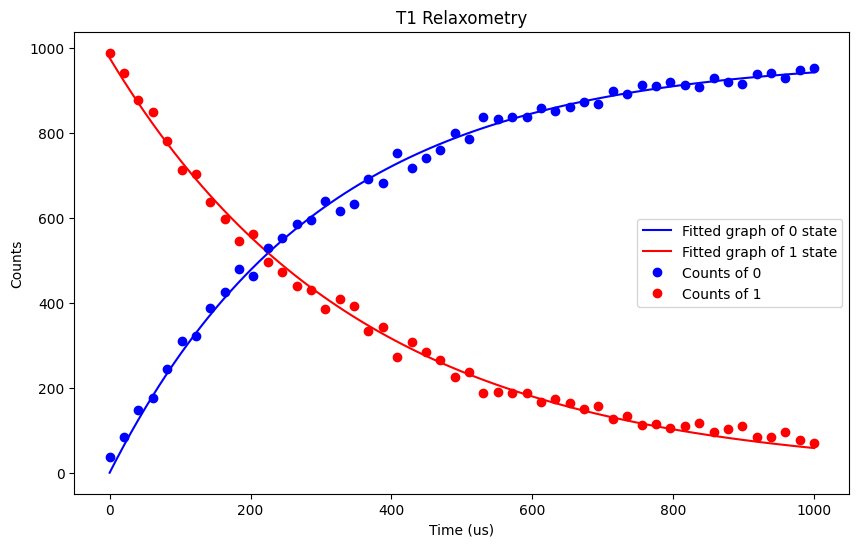

In [8]:

num_shots = 1024
time_max = 1000
num_time = 50
time = np.linspace(0, time_max, num_time)
results = []
circuits = []

for i in time:
    qr = QuantumRegister(1, 'q')
    cr = ClassicalRegister(1, 'c')
    qc = QuantumCircuit(qr, cr)
    qc.x(0)
    qc.delay(i, unit='us')
    qc.measure(0, 0)
    circuits.append(qc)

with Batch(backend=simulator) as batch:
    for i in circuits:
        sampler = Sampler(mode = batch)
        results.append(sampler.run([i], shots = num_shots).result()[0].data.c.get_counts())

# Fit function for T1 relaxation
def fit_func1(t, a, b):
    return a * (1 - np.exp(-t / b))

def fit_func2(t, a, b):
    return a * np.exp(-t / b)
# Fit the data to the T1 relaxation function
popt1, pcov1 = curve_fit(fit_func1, time, [result.get('0', 0) for result in results], p0=[1000, 1000])
popt2, pcov2 = curve_fit(fit_func2, time, [result.get('1', 0) for result in results], p0=[1000, 1000])

# Extract the T1 time from the fit parameters
T1_time1 = popt1[0]
T1_time2 = popt2[0]
print(f"T1 time (0 state): {T1_time1:.2f} us")
print(f"T1 time (1 state): {T1_time2:.2f} us")
# Plotting the fit results
x_fit = np.linspace(0, time_max, 100)
y_fit1 = fit_func1(x_fit, *popt1)
y_fit2 = fit_func2(x_fit, *popt2)
# calculate R2
def r_squared(y, y_fit):
    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - (ss_res / ss_tot)
r2_0 = r_squared([result.get('0', 0) for result in results], fit_func1(time,*popt1))
r2_1 = r_squared([result.get('1', 0) for result in results], fit_func2(time,*popt2))
print(f"R2 for 0 state: {r2_0:.4f}")
print(f"R2 for 1 state: {r2_1:.4f}")
# Plotting the results
plt.figure(figsize=(10, 6))
plt.title("T1 Relaxometry")
plt.xlabel("Time (us)")
plt.ylabel("Counts")
plt.plot(x_fit, y_fit1, 'b-', label='Fitted graph of 0 state')
plt.plot(x_fit, y_fit2, 'r-', label='Fitted graph of 1 state')
plt.plot(time, [result.get('0', 0) for result in results], 'bo', label='Counts of 0')
plt.plot(time, [result.get('1', 0) for result in results], 'ro', label='Counts of 1')
plt.legend()